In [18]:
import pandas as pd

def get_current_bonds(file_iter, N_patches, patch_molecule_map=None, pairs=False):
    current_bonds = set() # track current bonded pairs in this frame to compare with bonded_pairs dict
    clusters = pd.read_csv(file_iter, delimiter='\s+', header=None, nrows=N_patches, usecols=[0,1,5,6], names=['id', 'mol', 'patch_coord', 'patch_cluster'])
    bonded_clusters = clusters.loc[clusters['patch_coord'] > 0].copy() # filter only consider bonds with at least 1 patch (patch_coord is in column 5)
    bonded_clusters.sort_values(by='patch_cluster', inplace=True) # sort by patch_cluster (get bonded pairs) (patch_cluster is in column 6)
    bonded_clusters.reset_index(drop=True, inplace=True)

    arr = bonded_clusters.to_numpy()

    with open('temp.txt', "w") as f:
        for id in np.unique(clusters['id']):
            f.write(str(id) + "\n")

    for i in range(len(arr)-1):
        id1, id2 = int(arr[i, 0]), int(arr[i+1, 0]) # get ids of current and next cluster
        if int(arr[i, 2]) == int(arr[i+1, 2]): # if same patch_cluster, they are bonded
            if pairs:
                patch_molecule_map[id1] = int(arr[i, 1]) # map patch id to molecule id
                patch_molecule_map[id2] = int(arr[i+1, 1]) # map patch id to molecule id
                
                ids = (id1, id2) if id1 < id2 else (id2, id1) # order ids to avoid duplicates
                current_bonds.add(ids) # add to current bonds set
            else:
                current_bonds.add(id1) # add to current bonds set
                current_bonds.add(id2) # add to current bonds set
    
    return current_bonds

<>:5: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:5: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/tmp/ipykernel_16368/1213789484.py:5: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  clusters = pd.read_csv(file_iter, delimiter='\s+', header=None, nrows=N_patches, usecols=[0,1,5,6], names=['id', 'mol', 'patch_coord', 'patch_cluster'])


In [19]:
# given an association state s, we can convert it to a binary representation
def association_to_s(state):
    s = 0
    for i, val in enumerate(state):
        if val == 1:
            s += 2**i
    return s

In [ ]:
def count_s(bonded_pairs, patch_molecule_map, N_a=7, N_b=31, M=5, N_chains=800):
    bonded_patches = set() # track patches that are currently bonded
    molecule_ids = set() # track unique molecule ids that are currently bonded
    counts = {}

    for ids in bonded_pairs.keys():
        bonded_patches.add(ids[0])
        bonded_patches.add(ids[1])

        molecule_ids.add(patch_molecule_map[ids[0]])
        molecule_ids.add(patch_molecule_map[ids[1]])

    for mol_id in molecule_ids:
        state = [0] * N_a
        patches = [patch_id for patch_id, m_id in patch_molecule_map.items() if m_id == mol_id]

        for patch_id in patches:
            if patch_id in bonded_patches:
                state_id = patch_id - (N_b + N_a) * (mol_id - 1) - N_b
                state[state_id - 1] = 1

        s = association_to_s(state)
        counts[s] = counts.get(s, 0) + 1

    counts[0] = N_chains - len(molecule_ids)  # count unbonded chains (s=0)

    return counts

## $\nu^s$ algorithm with different $r_{\text{on}}, r_{\text{off}}$

Getting the number density of chains with a specific association state $s$, we can read a few (not too many, it will be a time series just to make sure it isn't too fluctuating) frames and return the density, so we also need the dimensions of the box. We can then compare it to the detailed balance assumption/result in equation 16 of Indei & Takimoto.


In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

"""
Process number density of association state s from clustering data file. Each frame of the file contains the following sections:
- "ITEM: TIMESTEP" followed by the timestep on the next line
- "ITEM: NUMBER OF ATOMS" followed by the number of entries on the next line
- "ITEM: ATOMS" followed by the data lines for each entry, with 7 values per line: id, mol, x, y, z, patch_coord, patch_cluster

Args:
    - filename_on: path to the clustering data file for determining bond creation
    - filename_off: path to the clustering data file for determining bond destruction
    - frames: number of frames to read, starting from the beginning
Returns:
    - count_time_series: dict with (time, counts) pairs where counts is dict with all valid s and their counts at that time
"""
def process_buffered_s_counts(filename_on, filename_off, frames=1, timestep=0.002):
    # init empty bond lifetime list
    bond_lifetimes = []
    # init empty bonded pair dict. lookup by (id1, id2) where id1 < id2 to avoid duplicates. value is start_time of the bond
    bonded_pairs = {}
    patch_molecule_map = {} # map patch id to molecule id

    count_time_series = {}

    N_patches = 0
    time = 0
    read_frames = 0
    with open(filename_on, 'r') as f_on:
        with open(filename_off, 'r') as f_off:
            while True:
                # stop reading BOTH if either file is done
                # reading f_on, only creating bonds
                line = f_on.readline()
                if not line:
                    break
                if line.startswith("ITEM: TIMESTEP"): # timestep is on next line
                    time = float(f_on.readline().strip()) * timestep # convert to time units
                    # print(f"Processing timestep: {time / timestep:.0f} (time units: {time})")
                elif line.startswith("ITEM: NUMBER OF ATOMS"): # number of entries is on next line
                    N_patches = int(f_on.readline().strip())
                elif line.startswith("ITEM: ATOMS"): # data starts on next line
                    current_bonds = get_current_bonds(f_on, N_patches, patch_molecule_map, pairs=True)
                    
                    for ids in current_bonds:
                        if ids not in bonded_pairs: # if new bond, add to bonded_pairs dict with start_time as current timestep
                            bonded_pairs[ids] = time

                # reading f_off, only breaking bonds
                line = f_off.readline()
                if not line:
                    break
                if line.startswith("ITEM: TIMESTEP"): # timestep is on next line
                    time = float(f_off.readline().strip()) * timestep # convert to time units
                    # print(f"Processing timestep: {time / timestep:.0f} (time units: {time})")
                elif line.startswith("ITEM: NUMBER OF ATOMS"): # number of entries is on next line
                    N_patches = int(f_off.readline().strip())
                elif line.startswith("ITEM: ATOMS"): # data starts on next line
                    current_bonds = get_current_bonds(f_off, N_patches, patch_molecule_map, pairs=True)

                    broken_bonds = bonded_pairs.keys() - current_bonds # bonds that are in bonded_pairs but not in current_bonds are broken
                    for ids in broken_bonds:
                        bonded_pairs.pop(ids) # remove from bonded_pairs and get start_time

                    # after processing broken bonds, go calculate number of chains in association state s
                    counts = count_s(bonded_pairs, patch_molecule_map)

                    count_time_series[time] = counts
                    read_frames += 1
                    if read_frames >= frames:
                        break
                    
    return count_time_series



In [22]:
box_length=30.785361074881
box_volume=box_length**3

## Generating life/offtime series

In [23]:
from joblib import Parallel, delayed
from time import time

# cutoffs = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
cutoffs = [0.4, 0.5, 0.6, 0.7]

As = [90, 100, 110, 120, 130]

def process_and_save_s_counts(cutoff_on, cutoff_off, A):
    start = time()
    filename_on = f"data/patches/{cutoff_on}prodpatch_chainlength_31_patchspacing_5_N_beads_24800_gaussA_{A}_r0_0.25_gaussB_10_seed_12345.bin.txt"
    filename_off = f"data/patches/{cutoff_off}prodpatch_chainlength_31_patchspacing_5_N_beads_24800_gaussA_{A}_r0_0.25_gaussB_10_seed_12345.bin.txt"
    s_counts = process_buffered_s_counts(filename_on, filename_off, frames=10000)
    s_counts_df = pd.DataFrame.from_dict(s_counts, orient="index")
    s_counts_df.index.name = "time"
    s_counts_df = s_counts_df.fillna(0).astype(int)
    s_counts_df.to_csv(f"data/s_states/buffered_s_counts_A{A}_cutoff_on{cutoff_on}_cutoff_off{cutoff_off}_r0_0.25.csv", index=False)
    print(f"Processed s_counts for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}, total s_counts recorded: {len(s_counts)} in {time() - start:.2f} seconds")

# only process lifetimes for cutoff_on < cutoff_off to avoid duplicates
# finish = Parallel(n_jobs=6)(delayed(process_and_save_s_counts)(cutoff_on, cutoff_off, A) for cutoff_on in cutoffs for cutoff_off in cutoffs if cutoff_on <= cutoff_off for A in As)




In [24]:
def extract_n_s(s, M, N_b):
    N_a = (N_b - 1) // M + 1
    if N_a < M:
        raise ValueError("N_a must be greater than or equal to M.")
    
    n_s = np.zeros(M * (N_a-1) + 1, dtype=int)

    index = 0
    while True:
        n_s[index] = s & 1
        s = s >> 1
        if s == 0:
            break
        if index >= M * (N_a-1):
            raise ValueError(f"s is too large to fit in the specified number of stickers and spacing, s^max = {2 ** N_a - 1}.")
        index += M
    return n_s

def count_associated(s, M=5, N_b=31):
    return np.sum(extract_n_s(s, M, N_b))

# n_c is density of chains
def nu_s(s, alpha, beta, M, N_b, n_c=1):
    N_a = (N_b - 1) // M + 1
    N_s = count_associated(s, M, N_b)
    return alpha**N_s * beta**(N_a - N_s) / (alpha + beta)**N_a * n_c

nu_s(s=127) = 0.0005083578627531545


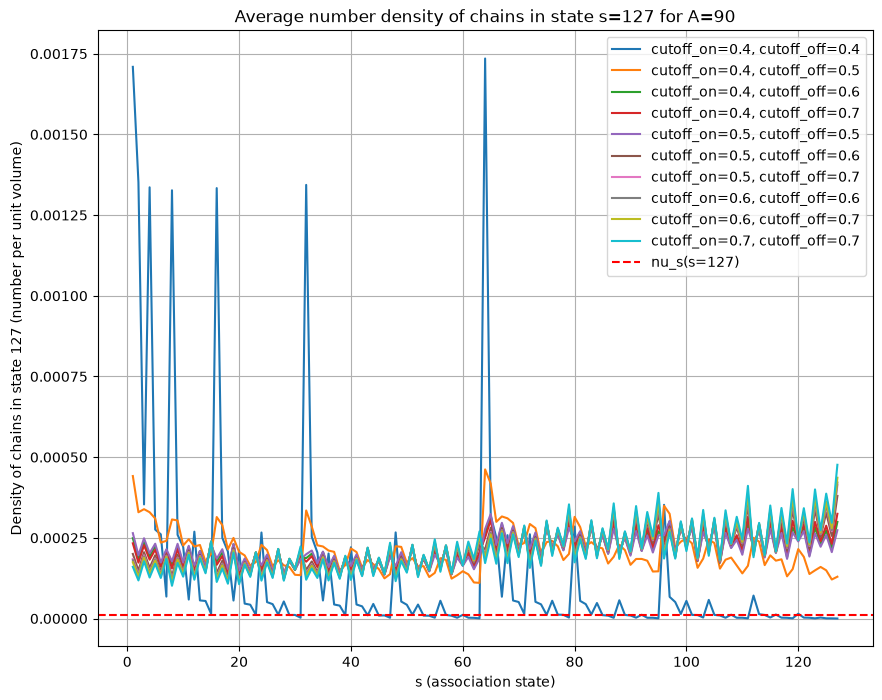

nu_s(s=127) = 0.0005083578627531545


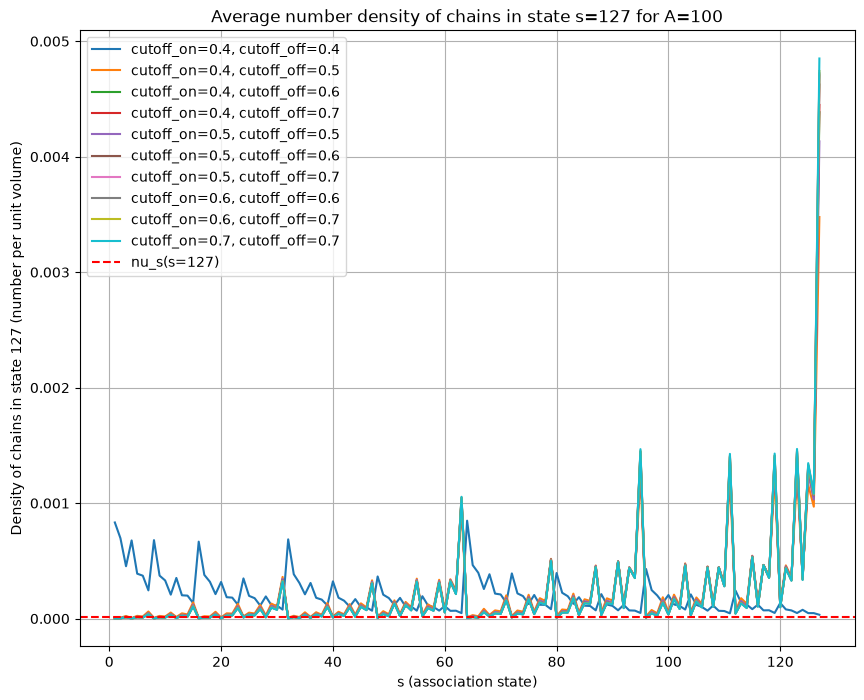

Did not find s=1 in the dataframe, setting nu_s_avg to 0.
Did not find s=4 in the dataframe, setting nu_s_avg to 0.
Did not find s=16 in the dataframe, setting nu_s_avg to 0.
Did not find s=36 in the dataframe, setting nu_s_avg to 0.
Did not find s=40 in the dataframe, setting nu_s_avg to 0.
Did not find s=1 in the dataframe, setting nu_s_avg to 0.
Did not find s=2 in the dataframe, setting nu_s_avg to 0.
Did not find s=3 in the dataframe, setting nu_s_avg to 0.
Did not find s=4 in the dataframe, setting nu_s_avg to 0.
Did not find s=5 in the dataframe, setting nu_s_avg to 0.
Did not find s=6 in the dataframe, setting nu_s_avg to 0.
Did not find s=8 in the dataframe, setting nu_s_avg to 0.
Did not find s=12 in the dataframe, setting nu_s_avg to 0.
Did not find s=16 in the dataframe, setting nu_s_avg to 0.
Did not find s=17 in the dataframe, setting nu_s_avg to 0.
Did not find s=18 in the dataframe, setting nu_s_avg to 0.
Did not find s=20 in the dataframe, setting nu_s_avg to 0.
Did no

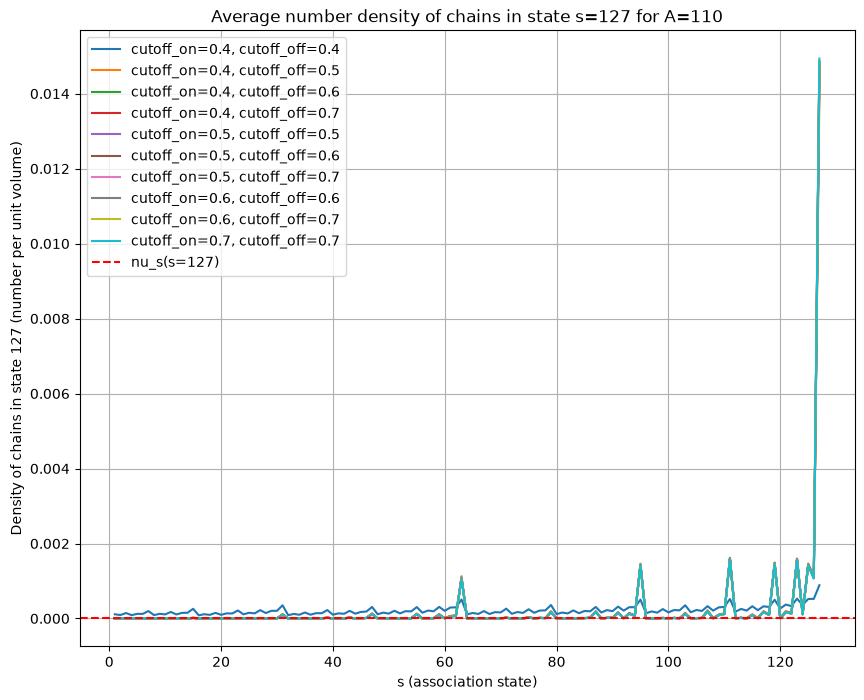

Did not find s=1 in the dataframe, setting nu_s_avg to 0.
Did not find s=2 in the dataframe, setting nu_s_avg to 0.
Did not find s=4 in the dataframe, setting nu_s_avg to 0.
Did not find s=6 in the dataframe, setting nu_s_avg to 0.
Did not find s=8 in the dataframe, setting nu_s_avg to 0.
Did not find s=10 in the dataframe, setting nu_s_avg to 0.
Did not find s=14 in the dataframe, setting nu_s_avg to 0.
Did not find s=17 in the dataframe, setting nu_s_avg to 0.
Did not find s=18 in the dataframe, setting nu_s_avg to 0.
Did not find s=20 in the dataframe, setting nu_s_avg to 0.
Did not find s=22 in the dataframe, setting nu_s_avg to 0.
Did not find s=24 in the dataframe, setting nu_s_avg to 0.
Did not find s=26 in the dataframe, setting nu_s_avg to 0.
Did not find s=32 in the dataframe, setting nu_s_avg to 0.
Did not find s=34 in the dataframe, setting nu_s_avg to 0.
Did not find s=36 in the dataframe, setting nu_s_avg to 0.
Did not find s=40 in the dataframe, setting nu_s_avg to 0.
Di

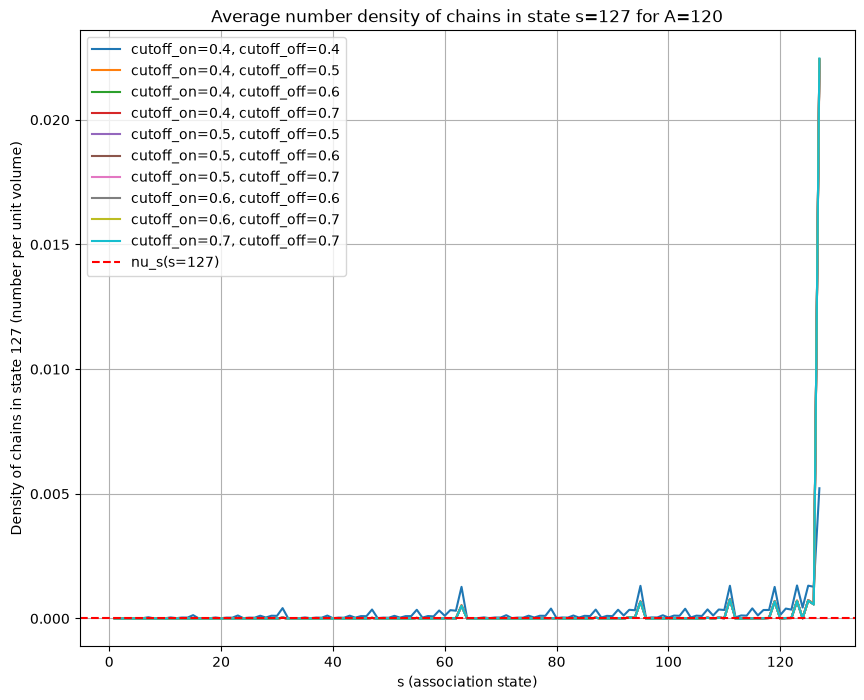

Did not find s=1 in the dataframe, setting nu_s_avg to 0.
Did not find s=2 in the dataframe, setting nu_s_avg to 0.
Did not find s=3 in the dataframe, setting nu_s_avg to 0.
Did not find s=4 in the dataframe, setting nu_s_avg to 0.
Did not find s=5 in the dataframe, setting nu_s_avg to 0.
Did not find s=6 in the dataframe, setting nu_s_avg to 0.
Did not find s=8 in the dataframe, setting nu_s_avg to 0.
Did not find s=9 in the dataframe, setting nu_s_avg to 0.
Did not find s=10 in the dataframe, setting nu_s_avg to 0.
Did not find s=11 in the dataframe, setting nu_s_avg to 0.
Did not find s=12 in the dataframe, setting nu_s_avg to 0.
Did not find s=13 in the dataframe, setting nu_s_avg to 0.
Did not find s=14 in the dataframe, setting nu_s_avg to 0.
Did not find s=16 in the dataframe, setting nu_s_avg to 0.
Did not find s=17 in the dataframe, setting nu_s_avg to 0.
Did not find s=18 in the dataframe, setting nu_s_avg to 0.
Did not find s=19 in the dataframe, setting nu_s_avg to 0.
Did n

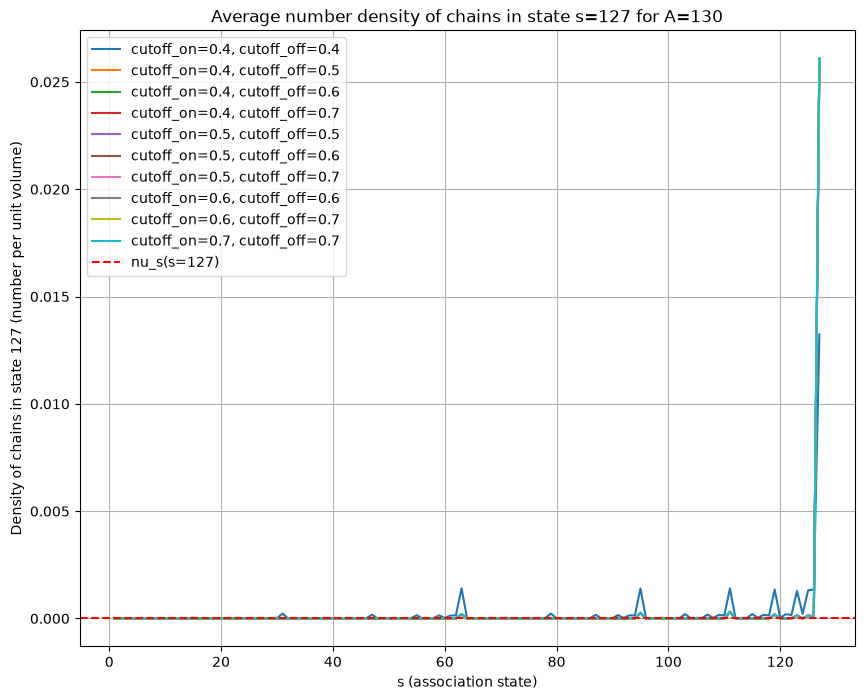

In [29]:

cutoffs = [0.4, 0.5, 0.6, 0.7]

As = [90, 100, 110, 120, 130]

times = np.arange(0, 20, 0.002) # 10000 samples
# s=2

for A in As:
    fig = plt.figure(figsize=(10,8))
    for cutoff_on in cutoffs:
        for cutoff_off in cutoffs:
            if cutoff_on <= cutoff_off: # only process lifetimes for cutoff_on < cutoff_off to avoid duplicates
                s_counts_df = pd.read_csv(f"data/s_states/buffered_s_counts_A{A}_cutoff_on{cutoff_on}_cutoff_off{cutoff_off}_r0_0.25.csv")
                s_list = np.arange(1, 128, 1)
                nu_s_avg_list = []
                for s in s_list:
                    try:
                        nu_s_avg_list.append(np.mean(s_counts_df[f'{s}']) / box_volume)  # Average number density of chains in state s
                    except KeyError:
                        nu_s_avg_list.append(0)
                        print(f"Did not find s={s} in the dataframe, setting nu_s_avg to 0.")
                plt.plot(s_list, nu_s_avg_list, label=f"cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")

                # plt.plot(times[:len(s_counts_df)], s_counts_df[f'{s}'], label=f"cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")



    plt.xlabel(f"s (association state)")
    plt.ylabel(f"Density of chains in state {s} (number per unit volume)")
    print(f"nu_s(s={s}) = {nu_s(s, 1/5.58, 1/7.27, 5, 31, 0.0274)}")
    plt.axhline(nu_s(s, 1/11.09, 1/5.42, 5, 31, 0.0274), color='r', linestyle='--', label=f"nu_s(s={s})")
    plt.title(f"Average number density of chains in state s={s} for A={A}")
    plt.grid(True)
    plt.legend()
    plt.show()

Did not find s=0 in the dataframe, setting num_associated to 0.
Did not find s=0 in the dataframe, setting num_associated to 0.
Did not find s=0 in the dataframe, setting num_associated to 0.
Did not find s=0 in the dataframe, setting num_associated to 0.
Did not find s=0 in the dataframe, setting num_associated to 0.
Did not find s=0 in the dataframe, setting num_associated to 0.
Did not find s=0 in the dataframe, setting num_associated to 0.
Did not find s=0 in the dataframe, setting num_associated to 0.
Did not find s=0 in the dataframe, setting num_associated to 0.
Did not find s=0 in the dataframe, setting num_associated to 0.
nu_s(s=127) = 0.0005083578627531545


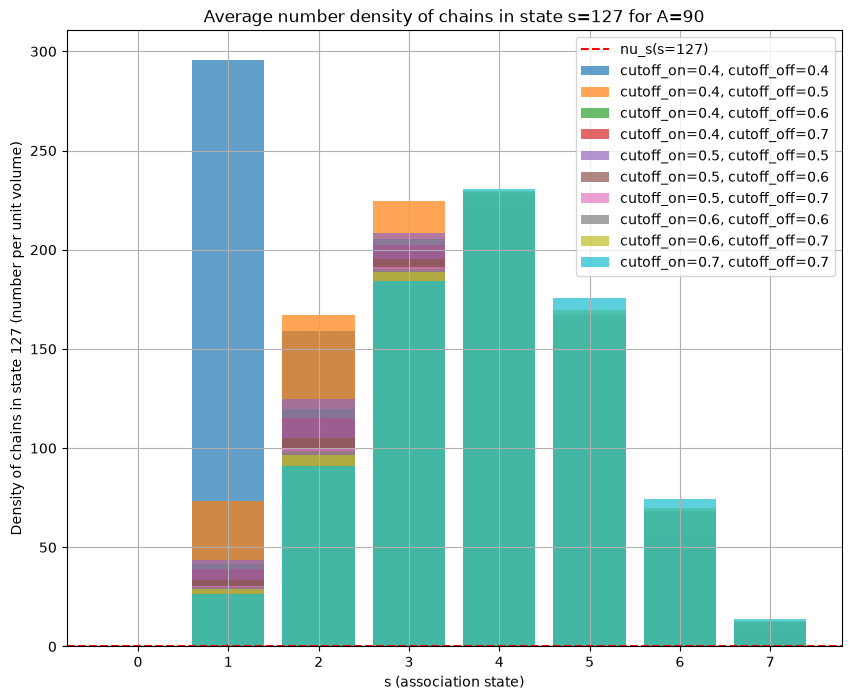

Did not find s=0 in the dataframe, setting num_associated to 0.
Did not find s=0 in the dataframe, setting num_associated to 0.
Did not find s=0 in the dataframe, setting num_associated to 0.
Did not find s=0 in the dataframe, setting num_associated to 0.
Did not find s=0 in the dataframe, setting num_associated to 0.
Did not find s=0 in the dataframe, setting num_associated to 0.
Did not find s=0 in the dataframe, setting num_associated to 0.
Did not find s=0 in the dataframe, setting num_associated to 0.
Did not find s=0 in the dataframe, setting num_associated to 0.
Did not find s=0 in the dataframe, setting num_associated to 0.
nu_s(s=127) = 0.0005083578627531545


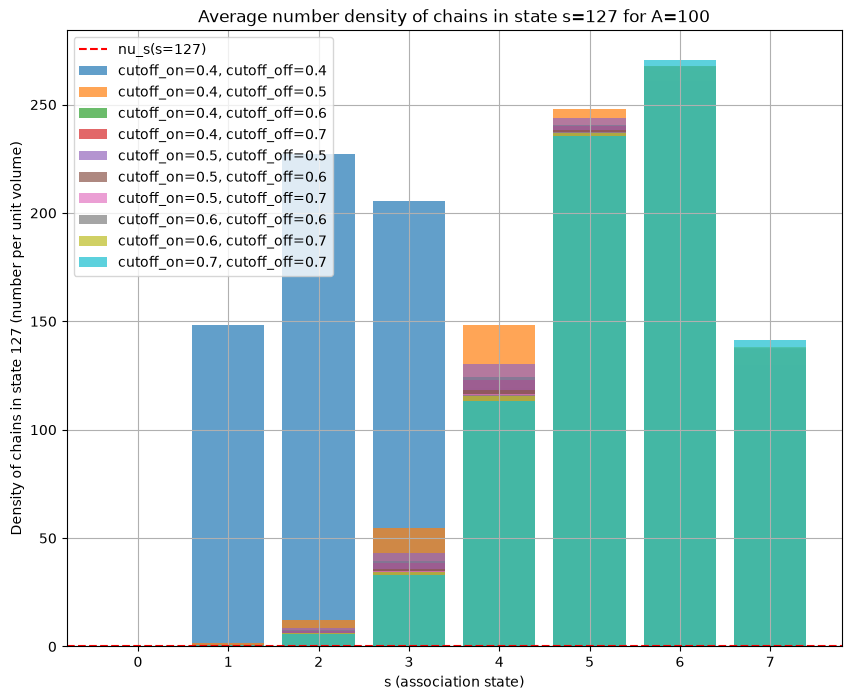

Did not find s=0 in the dataframe, setting num_associated to 0.
Did not find s=0 in the dataframe, setting num_associated to 0.
Did not find s=0 in the dataframe, setting num_associated to 0.
Did not find s=0 in the dataframe, setting num_associated to 0.
Did not find s=0 in the dataframe, setting num_associated to 0.
Did not find s=1 in the dataframe, setting num_associated to 0.
Did not find s=4 in the dataframe, setting num_associated to 0.
Did not find s=16 in the dataframe, setting num_associated to 0.
Did not find s=36 in the dataframe, setting num_associated to 0.
Did not find s=40 in the dataframe, setting num_associated to 0.
Did not find s=0 in the dataframe, setting num_associated to 0.
Did not find s=1 in the dataframe, setting num_associated to 0.
Did not find s=2 in the dataframe, setting num_associated to 0.
Did not find s=3 in the dataframe, setting num_associated to 0.
Did not find s=4 in the dataframe, setting num_associated to 0.
Did not find s=5 in the dataframe, se

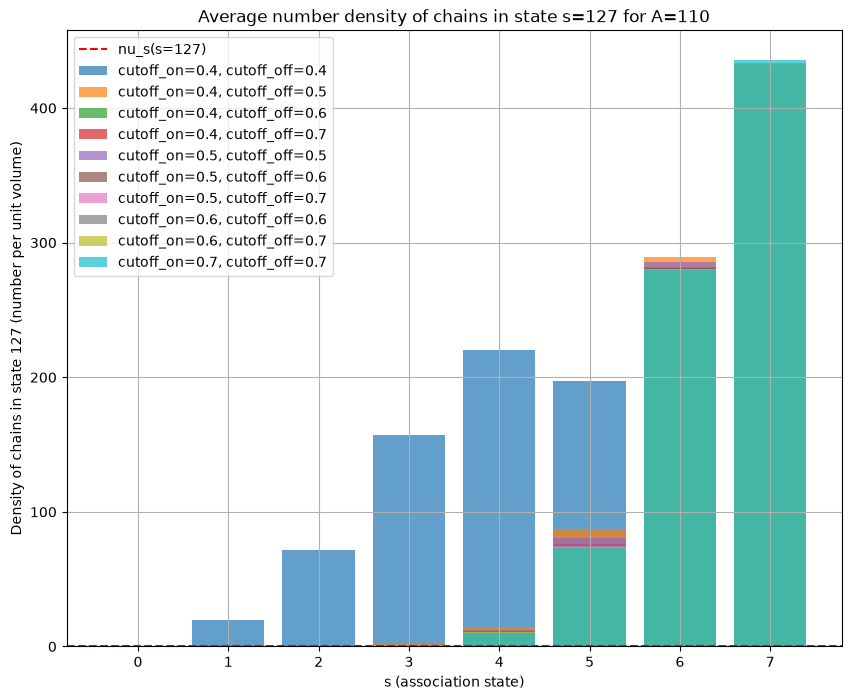

Did not find s=0 in the dataframe, setting num_associated to 0.
Did not find s=0 in the dataframe, setting num_associated to 0.
Did not find s=1 in the dataframe, setting num_associated to 0.
Did not find s=2 in the dataframe, setting num_associated to 0.
Did not find s=4 in the dataframe, setting num_associated to 0.
Did not find s=6 in the dataframe, setting num_associated to 0.
Did not find s=8 in the dataframe, setting num_associated to 0.
Did not find s=10 in the dataframe, setting num_associated to 0.
Did not find s=14 in the dataframe, setting num_associated to 0.
Did not find s=17 in the dataframe, setting num_associated to 0.
Did not find s=18 in the dataframe, setting num_associated to 0.
Did not find s=20 in the dataframe, setting num_associated to 0.
Did not find s=22 in the dataframe, setting num_associated to 0.
Did not find s=24 in the dataframe, setting num_associated to 0.
Did not find s=26 in the dataframe, setting num_associated to 0.
Did not find s=32 in the datafra

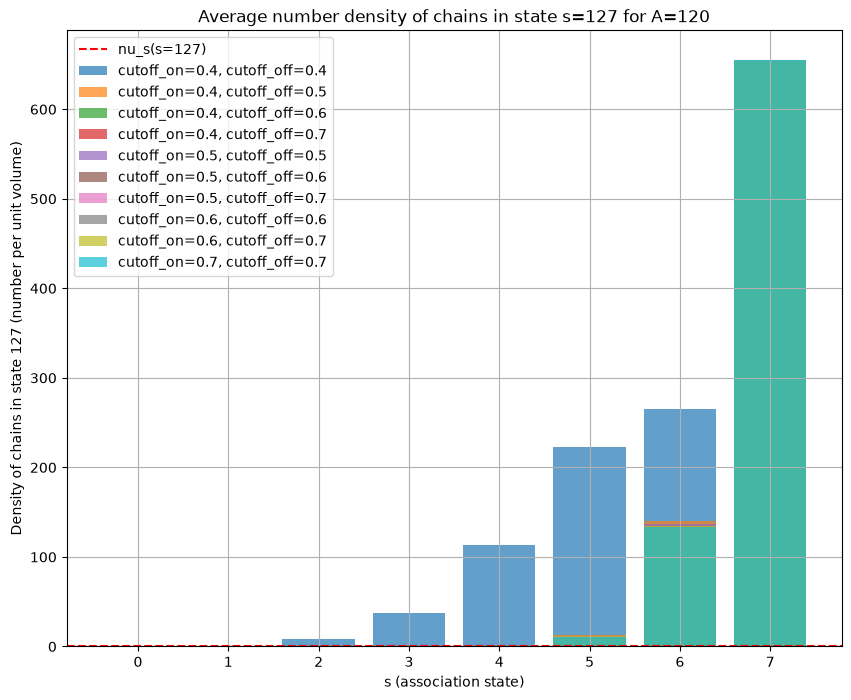

Did not find s=0 in the dataframe, setting num_associated to 0.
Did not find s=0 in the dataframe, setting num_associated to 0.
Did not find s=1 in the dataframe, setting num_associated to 0.
Did not find s=2 in the dataframe, setting num_associated to 0.
Did not find s=3 in the dataframe, setting num_associated to 0.
Did not find s=4 in the dataframe, setting num_associated to 0.
Did not find s=5 in the dataframe, setting num_associated to 0.
Did not find s=6 in the dataframe, setting num_associated to 0.
Did not find s=8 in the dataframe, setting num_associated to 0.
Did not find s=9 in the dataframe, setting num_associated to 0.
Did not find s=10 in the dataframe, setting num_associated to 0.
Did not find s=11 in the dataframe, setting num_associated to 0.
Did not find s=12 in the dataframe, setting num_associated to 0.
Did not find s=13 in the dataframe, setting num_associated to 0.
Did not find s=14 in the dataframe, setting num_associated to 0.
Did not find s=16 in the dataframe,

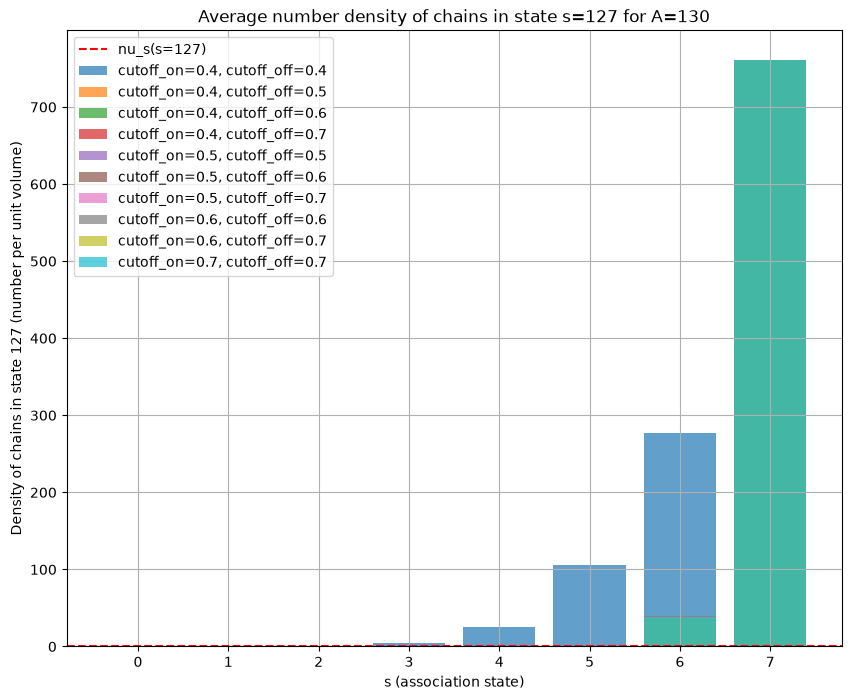

In [ ]:
cutoffs = [0.4, 0.5, 0.6, 0.7]

As = [90, 100, 110, 120, 130]

times = np.arange(0, 20, 0.002) # 10000 samples
# s=2

for A in As:
    fig = plt.figure(figsize=(10,8))
    for cutoff_on in cutoffs:
        for cutoff_off in cutoffs:
            if cutoff_on <= cutoff_off: # only process lifetimes for cutoff_on < cutoff_off to avoid duplicates
                s_counts_df = pd.read_csv(f"data/s_states/buffered_s_counts_A{A}_cutoff_on{cutoff_on}_cutoff_off{cutoff_off}_r0_0.25.csv")
                num_associated_list = {}
                for s in range(0, 128, 1):
                    try:
                        num_associated = count_associated(s)
                        if num_associated not in num_associated_list:
                            num_associated_list[num_associated] = 0
                        num_associated_list[num_associated] += np.mean(s_counts_df[f'{s}'])  # Average number density of chains in state s
                    except KeyError:
                        num_associated_list[count_associated(s)] = 0
                        print(f"Did not find s={s} in the dataframe, setting num_associated to 0.")
                plt.bar(num_associated_list.keys(), num_associated_list.values(), alpha=0.7, label=f"cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")

                # plt.plot(times[:len(s_counts_df)], s_counts_df[f'{s}'], label=f"cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")



    plt.xlabel(f"s (association state)")
    plt.ylabel(f"Density of chains in state {s} (number per unit volume)")
    # print(f"nu_s(s={s}) = {nu_s(s, 1/5.58, 1/7.27, 5, 31, 0.0274)}")
    plt.axhline(nu_s(s, 1/11.09, 1/5.42, 5, 31, 0.0274), color='r', linestyle='--', label=f"nu_s(s={s})")
    plt.title(f"Average number density of chains in state s={s} for A={A}")
    plt.grid(True)
    plt.legend()
    plt.show()